# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pengaturan gaya tampilan grafik
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Data & Preprocessing

In [2]:
# Load dataset hasil ekspor MySQL
df = pd.read_csv('hr_cleaned_data.csv')

# Cek struktur & 5 baris pertama
print("Ukuran Data:", df.shape)
df.head()

Ukuran Data: (1470, 29)


,employee_id,age,gender,marital_status,education_level,education_field,department,job_role,job_level,monthly_income,...,job_involvement,job_satisfaction,performance_rating,relationship_satisfaction,work_life_balance,business_travel,distance_from_home,num_companies_worked,over_time,attrition
0,1,41,Female,Single,2,Life Sciences,Sales,Sales Executive,2,5993,...,3,4,3,1,1,Travel_Rarely,1,8,Yes,Yes
1,2,49,Male,Married,1,Life Sciences,Research & Development,Research Scientist,2,5130,...,2,2,4,4,3,Travel_Frequently,8,1,No,No
2,4,37,Male,Single,2,Other,Research & Development,Laboratory Technician,1,2090,...,2,3,3,2,3,Travel_Rarely,2,6,Yes,Yes
3,5,33,Female,Married,4,Life Sciences,Research & Development,Research Scientist,1,2909,...,3,3,3,3,3,Travel_Frequently,3,1,Yes,No
4,7,27,Male,Married,1,Medical,Research & Development,Laboratory Technician,1,3468,...,3,2,3,4,3,Travel_Rarely,2,9,No,No


In [3]:
# Mementingkan urutan kategori kepuasan kerja & work life balance
satisfaction_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}
df['job_satisfaction_label'] = df['job_satisfaction'].map(satisfaction_map)
df['work_life_balance_label'] = df['work_life_balance'].map(satisfaction_map)

# Konversi Target Attrition ke angka untuk kalkulasi korelasi
df['attrition_numeric'] = df['attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Visualisasi dan Analisi Korelasi

### Distribusi Target (Attrition Rate Overview)

C:\Users\Radja Triyasa\AppData\Local\Temp\ipykernel_4832\2326904108.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='attrition', palette=['#2b5c8f', '#d9534f'])


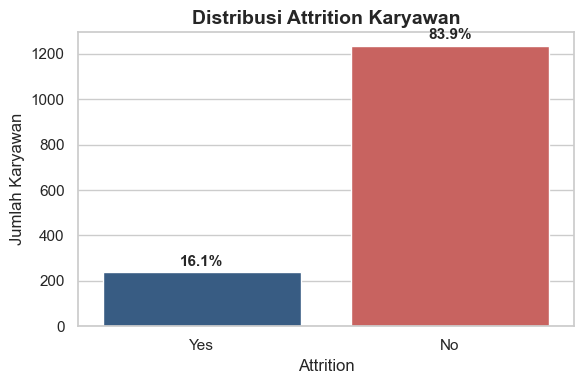

In [4]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='attrition', palette=['#2b5c8f', '#d9534f'])
plt.title('Distribusi Attrition Karyawan', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Jumlah Karyawan')

# Menambahkan persentase di atas batang
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

### Dampak Lembur (OverTime) & Kepuasan Kerja terhadap Attrition

C:\Users\Radja Triyasa\AppData\Local\Temp\ipykernel_4832\1476939579.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='over_time', y='attrition_numeric', ax=axes[0], ci=None, palette='Reds')
C:\Users\Radja Triyasa\AppData\Local\Temp\ipykernel_4832\1476939579.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='over_time', y='attrition_numeric', ax=axes[0], ci=None, palette='Reds')
C:\Users\Radja Triyasa\AppData\Local\Temp\ipykernel_4832\1476939579.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='job_satisfaction_label', y='attrition_numeric',
C:\Users\Radja Triyasa\AppData\Local\Temp\ipykernel_4832\1476939579.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is d

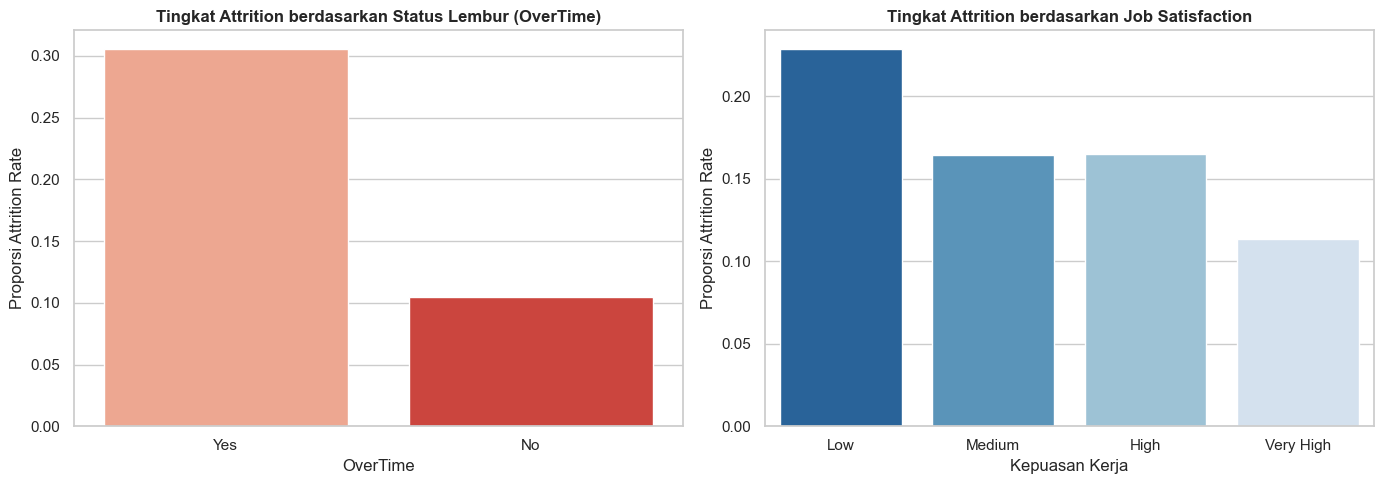

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# OverTime vs Attrition
sns.barplot(data=df, x='over_time', y='attrition_numeric', ax=axes[0], ci=None, palette='Reds')
axes[0].set_title('Tingkat Attrition berdasarkan Status Lembur (OverTime)', fontweight='bold')
axes[0].set_ylabel('Proporsi Attrition Rate')
axes[0].set_xlabel('OverTime')

# Job Satisfaction vs Attrition
sns.barplot(data=df, x='job_satisfaction_label', y='attrition_numeric', 
            order=['Low', 'Medium', 'High', 'Very High'], ax=axes[1], ci=None, palette='Blues_r')
axes[1].set_title('Tingkat Attrition berdasarkan Job Satisfaction', fontweight='bold')
axes[1].set_ylabel('Proporsi Attrition Rate')
axes[1].set_xlabel('Kepuasan Kerja')

plt.tight_layout()
plt.show()

### Distribusi Monthly Income & Age (Boxplot Analysis)

C:\Users\Radja Triyasa\AppData\Local\Temp\ipykernel_4832\3766347705.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='attrition', y='monthly_income', ax=axes[0], palette=['#2b5c8f', '#d9534f'])
C:\Users\Radja Triyasa\AppData\Local\Temp\ipykernel_4832\3766347705.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='attrition', y='age', ax=axes[1], palette=['#2b5c8f', '#d9534f'])


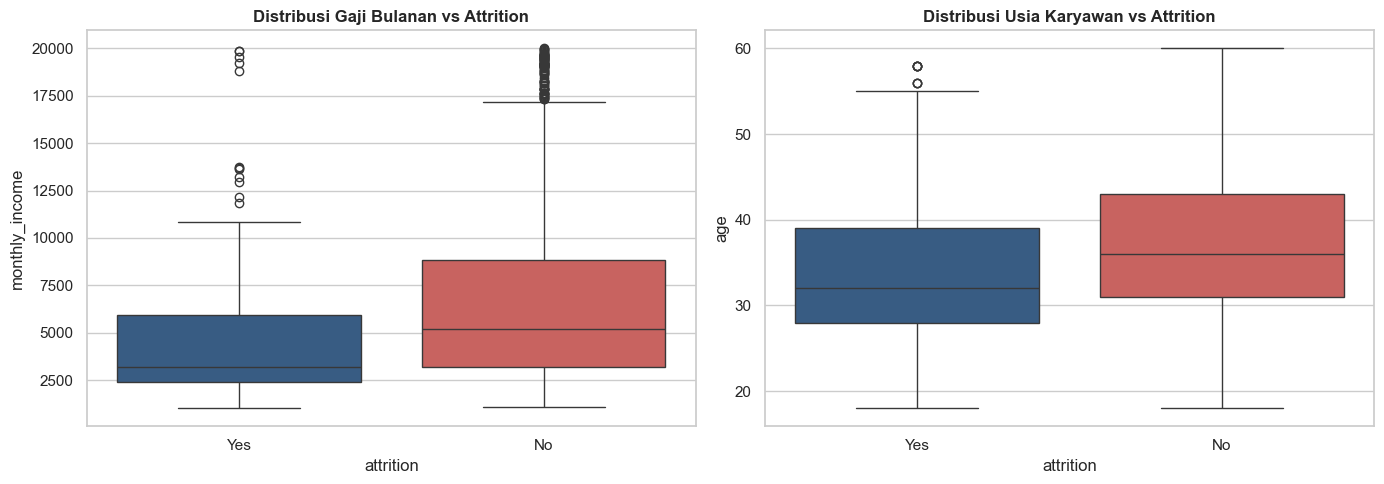

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly Income Distribution
sns.boxplot(data=df, x='attrition', y='monthly_income', ax=axes[0], palette=['#2b5c8f', '#d9534f'])
axes[0].set_title('Distribusi Gaji Bulanan vs Attrition', fontweight='bold')

# Age Distribution
sns.boxplot(data=df, x='attrition', y='age', ax=axes[1], palette=['#2b5c8f', '#d9534f'])
axes[1].set_title('Distribusi Usia Karyawan vs Attrition', fontweight='bold')

plt.tight_layout()
plt.show()

# Identifikasi Profil Karyawan Berisiko Tinggi (High-Risk Segments)

In [7]:
# Karyawan berisiko tinggi: OverTime = Yes & Monthly Income < Median & WorkLifeBalance <= 2
high_risk_condition = (
    (df['over_time'] == 'Yes') & 
    (df['monthly_income'] < df['monthly_income'].median()) & 
    (df['work_life_balance'] <= 2)
)

high_risk_df = df[high_risk_condition]
high_risk_attrition_rate = high_risk_df['attrition_numeric'].mean() * 100

print(f"Jumlah Karyawan Segmen Risiko Tinggi: {len(high_risk_df)}")
print(f"Attrition Rate pada Segmen Risiko Tinggi: {high_risk_attrition_rate:.2f}%")

Jumlah Karyawan Segmen Risiko Tinggi: 65
Attrition Rate pada Segmen Risiko Tinggi: 41.54%


# Dokumentasi Insights

In [11]:
print(f"1. Distribusi Attrition (Baseline Rate): Terdapat 16.1% (237 karyawan) yang keluar/resign dari total 1.470 karyawan.")
print(f"2. Dampak OverTime (Lembur): Karyawan dengan status lembur (OverTime = Yes) memiliki tingkat attrition melonjak hingga >30%, hampir 3x lipat dibanding karyawan yang tidak lembur (~10%)")
print(f"3. Kepuasan Kerja (Job Satisfaction): Karyawan yang menyatakan tingkat kepuasan kerja 'Low' memiliki proporsi attrition tertinggi (~23%), sementara kelompok 'Very High' hanya ~11%.")
print(f"4. Faktor Kompensasi & Usia: Median gaji (Monthly Income) karyawan yang resign jauh lebih rendah dibandingkan karyawan yang bertahan. Begitu juga dari sisi usia, kelompok usia muda (20–30 tahun) memiliki tingkat turnover lebih tinggi.")
print(f"5.Segmen Risiko Tinggi (High-Risk Segment): Berhasil mengidentifikasi 65 karyawan yang sering lembur, bergaji di bawah median, dan work-life balance rendah, dengan tingkat attrition sangat kritis mencapai 41.54%!")

1. Distribusi Attrition (Baseline Rate): Terdapat 16.1% (237 karyawan) yang keluar/resign dari total 1.470 karyawan.
2. Dampak OverTime (Lembur): Karyawan dengan status lembur (OverTime = Yes) memiliki tingkat attrition melonjak hingga >30%, hampir 3x lipat dibanding karyawan yang tidak lembur (~10%)
3. Kepuasan Kerja (Job Satisfaction): Karyawan yang menyatakan tingkat kepuasan kerja 'Low' memiliki proporsi attrition tertinggi (~23%), sementara kelompok 'Very High' hanya ~11%.
4. Faktor Kompensasi & Usia: Median gaji (Monthly Income) karyawan yang resign jauh lebih rendah dibandingkan karyawan yang bertahan. Begitu juga dari sisi usia, kelompok usia muda (20–30 tahun) memiliki tingkat turnover lebih tinggi.
5.Segmen Risiko Tinggi (High-Risk Segment): Berhasil mengidentifikasi 65 karyawan yang sering lembur, bergaji di bawah median, dan work-life balance rendah, dengan tingkat attrition sangat kritis mencapai 41.54%!
